<h5> Dataset 3 (SMOTE) — Imports and load outer-train data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, validation_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

# Load ONLY the 70% outer-train — the OG 30% test set is never touched in this notebook
X_train_outer = pd.read_csv('X_train_clean.csv')
y_train_outer = pd.read_csv('y_train_clean.csv').squeeze()

print(f"Outer-train shape: {X_train_outer.shape}")
print(f"Outer-train class distribution:\n{y_train_outer.value_counts()}")

c:\SID\Anaconda3\envs\apoorva_ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Outer-train shape: (16819, 50)
Outer-train class distribution:
default payment next month
0    16354
1      465
Name: count, dtype: int64


<h5> Reusable evaluation function

In [3]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    print(f"===== {model_name} =====")
    print("\n--- Training Set Performance (balanced inner-train) ---")
    print(classification_report(y_train, y_train_pred, digits=3))
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

    print("\n--- Inner-Validation Performance (real, imbalanced) ---")
    print(classification_report(y_val, y_val_pred, digits=3))
    print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")

    roc_auc_train = roc_auc_score(y_train, y_train_proba)
    roc_auc_val = roc_auc_score(y_val, y_val_proba)
    pr_auc_train = average_precision_score(y_train, y_train_proba)
    pr_auc_val = average_precision_score(y_val, y_val_proba)

    print(f"\nTrain ROC-AUC: {roc_auc_train:.4f} | Validation ROC-AUC: {roc_auc_val:.4f}")
    print(f"Train PR-AUC:  {pr_auc_train:.4f} | Validation PR-AUC:  {pr_auc_val:.4f}")

    cm = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix (Inner-Validation)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    plt.figure(figsize=(8,6))
    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='No Skill')
    plt.plot(fpr, tpr, color='orange', label=f'{model_name} (AUC = {roc_auc_val:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve (Inner-Validation)')
    plt.legend()
    plt.show()

    precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
    no_skill = y_val.sum() / len(y_val)
    plt.figure(figsize=(8,6))
    plt.plot([0,1], [no_skill, no_skill], linestyle='--', color='gray', label='No Skill')
    plt.plot(recall, precision, color='orange', label=f'{model_name} (AUC = {pr_auc_val:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - Precision-Recall Curve (Inner-Validation)')
    plt.legend()
    plt.show()

    filename = f"{model_name.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')}.pkl"
    pickle.dump(model, open(filename, 'wb'))
    print(f"\nModel saved as: {filename}")

    return {'model_name': model_name,
            'accuracy_train': accuracy_score(y_train, y_train_pred), 'accuracy_val': accuracy_score(y_val, y_val_pred),
            'precision_val': precision_score(y_val, y_val_pred), 'recall_val': recall_score(y_val, y_val_pred),
            'f1_val': f1_score(y_val, y_val_pred),
            'roc_auc_train': roc_auc_train, 'roc_auc_val': roc_auc_val,
            'pr_auc_train': pr_auc_train, 'pr_auc_val': pr_auc_val}

<h5> learning curve and validation curve functions

In [4]:
def plot_learning_curve(estimator, X, y, model_name, cv=5, scoring='f1'):
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1)
    cv_std = cv_scores.std(axis=1)

    plt.figure(figsize=(9,6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, cv_mean, 'o-', color='orange', label='Cross-validation score')
    plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color='orange')
    plt.xlabel('Training Set Size')
    plt.ylabel(f'{scoring.upper()} Score')
    plt.title(f'{model_name} - Learning Curve (within resampled inner-train)')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    gap = train_mean[-1] - cv_mean[-1]
    print(f"Final training score: {train_mean[-1]:.3f}")
    print(f"Final CV score: {cv_mean[-1]:.3f}")
    print(f"Train-CV gap: {gap:.3f}")
    return gap


def plot_validation_curve(estimator, X, y, param_name, param_range, model_name, cv=5, scoring='f1', param_range_display=None):
    train_scores, cv_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    cv_mean = cv_scores.mean(axis=1)

    x_vals = param_range_display if param_range_display is not None else param_range

    plt.figure(figsize=(9,6))
    plt.plot(x_vals, train_mean, 'o-', color='blue', label='Training score')
    plt.plot(x_vals, cv_mean, 'o-', color='orange', label='Cross-validation score')
    plt.xlabel(param_name)
    plt.ylabel(f'{scoring.upper()} Score')
    plt.title(f'{model_name} - Validation Curve ({param_name})')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

<h5> SHAP function

In [5]:
def plot_shap_analysis(model, X_data, model_name, max_display=15):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_data)

    # Binary classifiers: SHAP returns values for both classes — take class 1 (default)
    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    print(f"===== {model_name} — SHAP Analysis (Inner-Validation) =====")

    # Global feature importance (bar)
    shap.plots.bar(shap_values, max_display=max_display, show=False)
    plt.title(f'{model_name} - SHAP Feature Importance')
    plt.tight_layout()
    plt.show()

    # Beeswarm (impact + direction per feature)
    shap.plots.beeswarm(shap_values, max_display=max_display, show=False)
    plt.title(f'{model_name} - SHAP Summary (Beeswarm)')
    plt.tight_layout()
    plt.show()

    return shap_values


def plot_shap_waterfall(shap_values, index, model_name):
    print(f"===== {model_name} — Individual Prediction Explanation (row {index}) =====")
    shap.plots.waterfall(shap_values[index], show=False)
    plt.title(f'{model_name} - Waterfall (row {index})')
    plt.tight_layout()
    plt.show()

<h5> Inner split FIRST (stratified, shared across Datasets 1/2/3) — 80:20 into inner-train-raw / inner-validation

In [6]:
X_inner_train_raw, X_inner_val, y_inner_train_raw, y_inner_val = train_test_split(
    X_train_outer, y_train_outer, test_size=0.2, random_state=42, stratify=y_train_outer
)

print(f"Inner-train-raw (pre-resampling) shape: {X_inner_train_raw.shape}")
print(f"Inner-validation (real, untouched, shared across Datasets 1/2/3) shape: {X_inner_val.shape}")
print(f"\nInner-train-raw class distribution:\n{y_inner_train_raw.value_counts()}")
print(f"\nInner-validation class distribution:\n{y_inner_val.value_counts()}")

Inner-train-raw (pre-resampling) shape: (13455, 50)
Inner-validation (real, untouched, shared across Datasets 1/2/3) shape: (3364, 50)

Inner-train-raw class distribution:
default payment next month
0    13083
1      372
Name: count, dtype: int64

Inner-validation class distribution:
default payment next month
0    3271
1      93
Name: count, dtype: int64


<h5> Build Dataset 3 (SMOTE) from inner-train-raw only — scale first, then SMOTE

In [7]:
# Fit scaler on inner-train-raw ONLY (fit-on-train-only discipline)
scaler = StandardScaler()
X_inner_train_raw_scaled = pd.DataFrame(
    scaler.fit_transform(X_inner_train_raw),
    columns=X_inner_train_raw.columns,
    index=X_inner_train_raw.index
)

# Inner-validation transformed with the SAME fitted scaler
X_inner_val = pd.DataFrame(
    scaler.transform(X_inner_val),
    columns=X_inner_val.columns,
    index=X_inner_val.index
)

smote = SMOTE(random_state=42)
X_inner_train, y_inner_train = smote.fit_resample(X_inner_train_raw_scaled, y_inner_train_raw)

print(f"Inner-train (balanced, post-SMOTE) shape: {X_inner_train.shape}")
print(f"Inner-train (balanced) class distribution:\n{pd.Series(y_inner_train).value_counts()}")

Inner-train (balanced, post-SMOTE) shape: (26166, 50)
Inner-train (balanced) class distribution:
default payment next month
0    13083
1    13083
Name: count, dtype: int64


<h5> Random Forest: train + tune (RandomizedSearchCV)

Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
===== Random Forest (Dataset 3 - SMOTE) =====

--- Training Set Performance (balanced inner-train) ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     13083
           1      1.000     1.000     1.000     13083

    accuracy                          1.000     26166
   macro avg      1.000     1.000     1.000     26166
weighted avg      1.000     1.000     1.000     26166

Training Accuracy: 1.0000

--- Inner-Validation Performance (real, imbalanced) ---
              precision    recall  f1-score   support

           0      0.974     0.991     0.983      3271
           1      0.211     0.086     0.122        93

    accuracy                          0.966      3364
   macro avg      0.592     0.538     0.552      3364
weighted avg      0.953     0.966     0.959      3364

Validation Accuracy: 0.9658

Train ROC-AUC: 1.0000 | Val

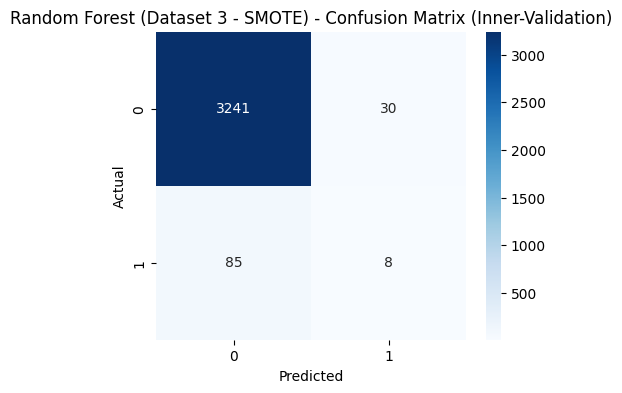

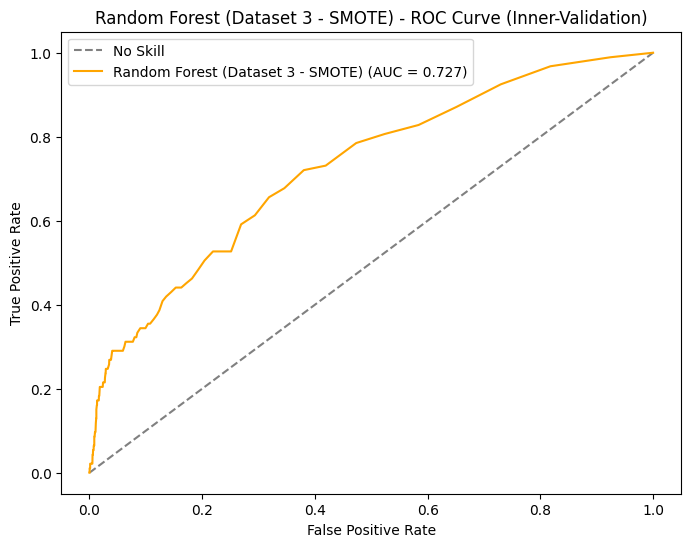

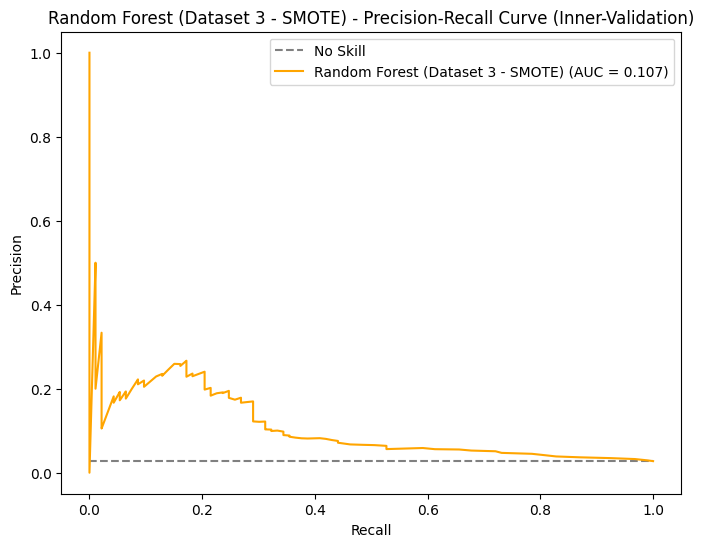


Model saved as: Random_Forest_Dataset_3_-_SMOTE.pkl


In [8]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)

rf_search.fit(X_inner_train, y_inner_train)
print(f"Best RF params: {rf_search.best_params_}")

rf_best = rf_search.best_estimator_
rf_results = evaluate_model(rf_best, X_inner_train, y_inner_train, X_inner_val, y_inner_val, "Random Forest (Dataset 3 - SMOTE)")

<h5> Overfitting check — Learning Curve (Random Forest)

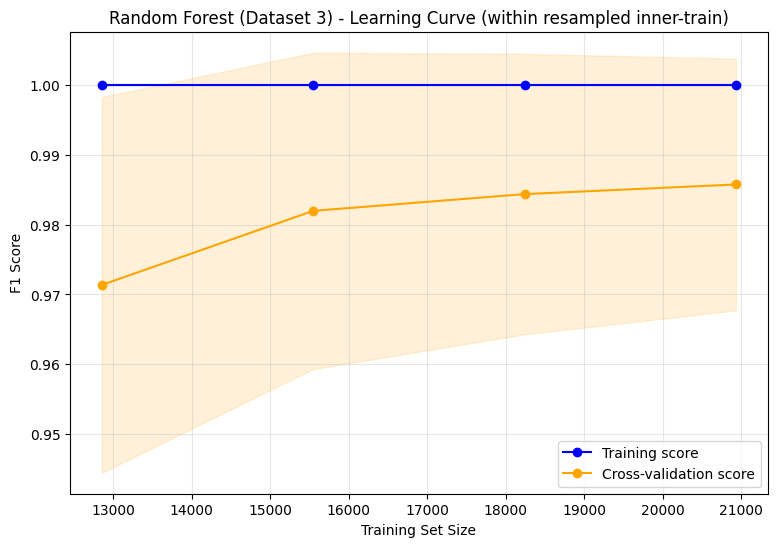

Final training score: 1.000
Final CV score: 0.986
Train-CV gap: 0.014


In [9]:
rf_gap = plot_learning_curve(rf_best, X_inner_train, y_inner_train, "Random Forest (Dataset 3)")

<h5> Overfitting check — Validation Curve (Random Forest, max_depth)

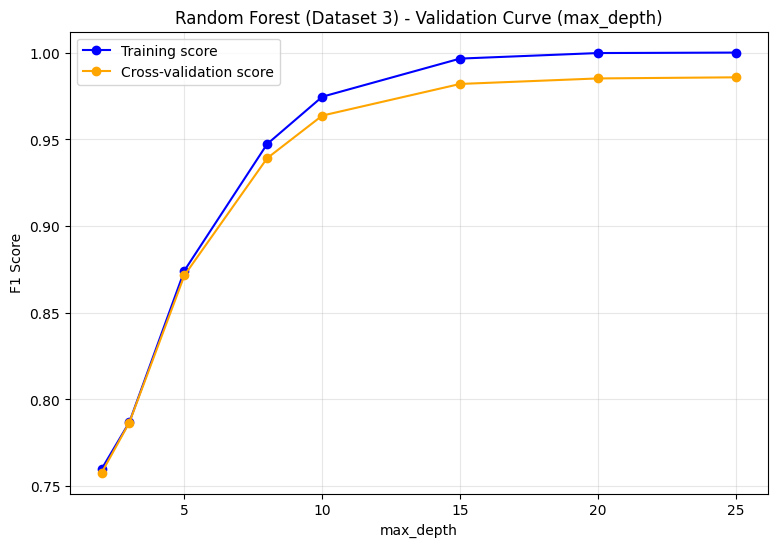

In [10]:
depth_range = [2, 3, 5, 8, 10, 15, 20, None]
depth_range_display = [d if d is not None else 25 for d in depth_range]

plot_validation_curve(
    RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=rf_search.best_params_['n_estimators'],
                            min_samples_split=rf_search.best_params_['min_samples_split'],
                            min_samples_leaf=rf_search.best_params_['min_samples_leaf']),
    X_inner_train, y_inner_train, param_name='max_depth', param_range=depth_range,
    model_name="Random Forest (Dataset 3)", param_range_display=depth_range_display
)

<h5> SHAP Analysis — Random Forest (Dataset 3)

===== Random Forest (Dataset 3 - SMOTE) — SHAP Analysis (Inner-Validation) =====


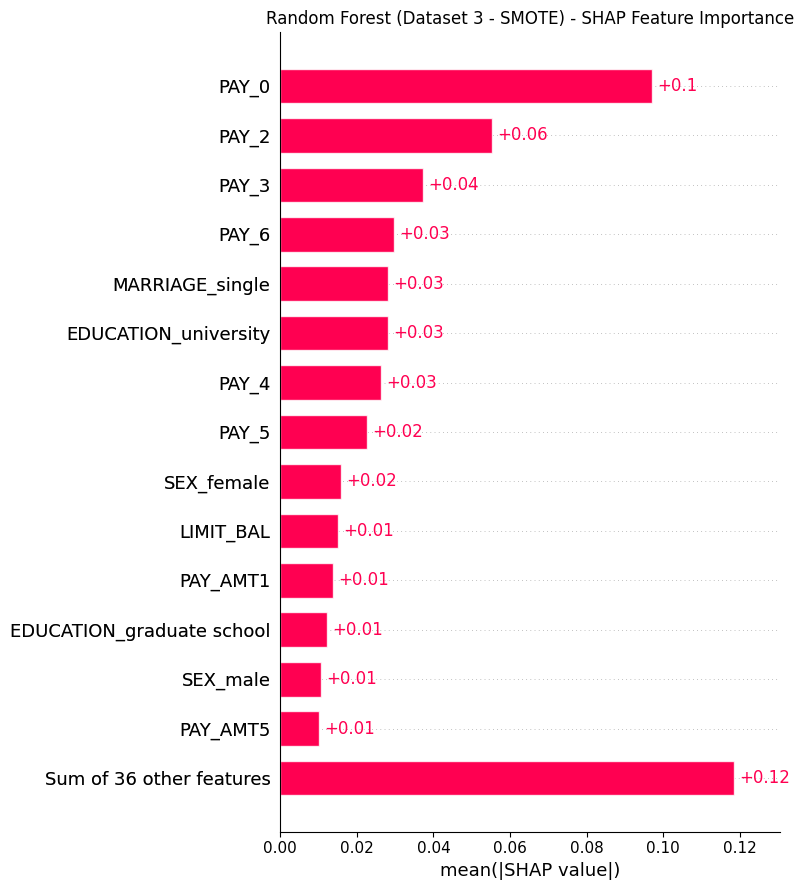

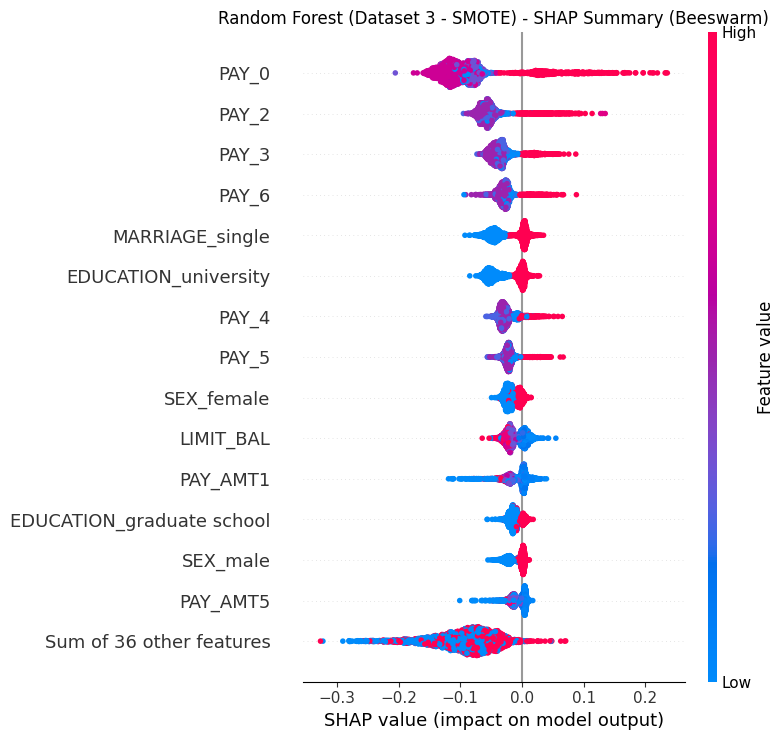

In [11]:
rf_shap_values = plot_shap_analysis(rf_best, X_inner_val, "Random Forest (Dataset 3 - SMOTE)")

<h5> XGBoost: train + tune (RandomizedSearchCV)

Best XGBoost params: {'reg_lambda': 5, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.1}
===== XGBoost (Dataset 3 - SMOTE) =====

--- Training Set Performance (balanced inner-train) ---
              precision    recall  f1-score   support

           0      0.999     1.000     0.999     13083
           1      1.000     0.999     0.999     13083

    accuracy                          0.999     26166
   macro avg      0.999     0.999     0.999     26166
weighted avg      0.999     0.999     0.999     26166

Training Accuracy: 0.9994

--- Inner-Validation Performance (real, imbalanced) ---
              precision    recall  f1-score   support

           0      0.973     0.994     0.984      3271
           1      0.174     0.043     0.069        93

    accuracy                          0.968      3364
   macro avg      0.574     0.519     0.526      3364
weighted avg      0.951     0.968     0.958      3364

Validation Accuracy: 0.9679

Train ROC-AUC: 1.0000 | V

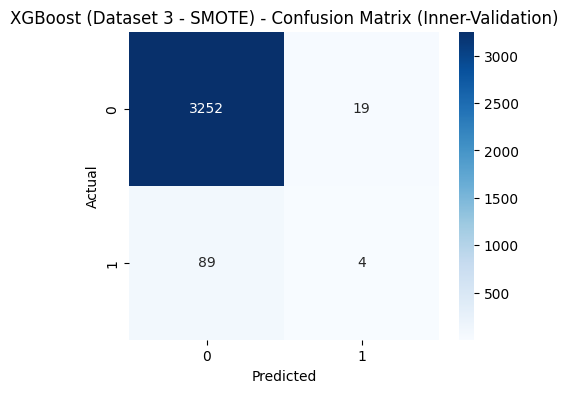

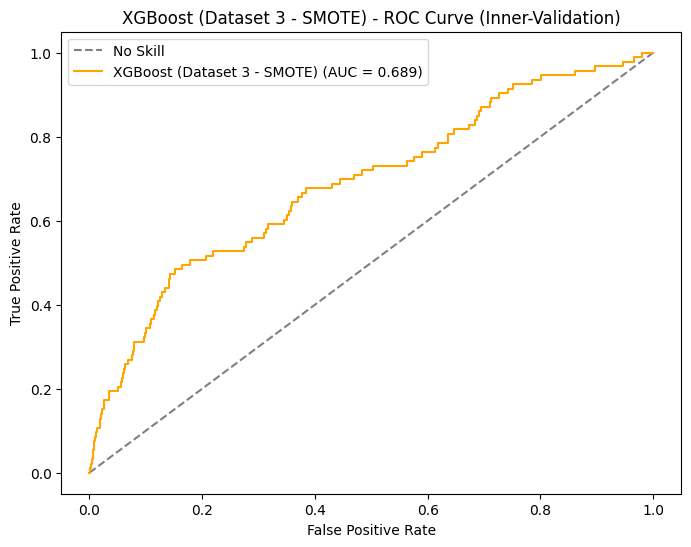

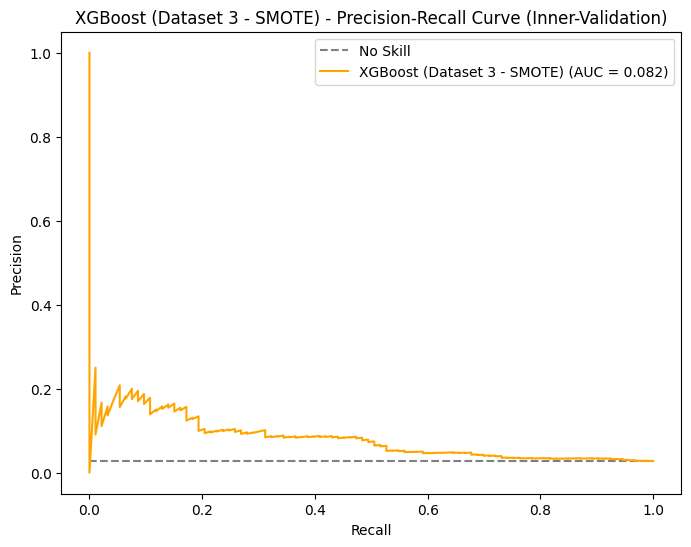


Model saved as: XGBoost_Dataset_3_-_SMOTE.pkl


In [12]:
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'reg_lambda': [1, 2, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='auc'),
    param_distributions=xgb_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)

xgb_search.fit(X_inner_train, y_inner_train)
print(f"Best XGBoost params: {xgb_search.best_params_}")

xgb_best = xgb_search.best_estimator_
xgb_results = evaluate_model(xgb_best, X_inner_train, y_inner_train, X_inner_val, y_inner_val, "XGBoost (Dataset 3 - SMOTE)")

<h5> Overfitting check — Learning Curve (XGBoost)

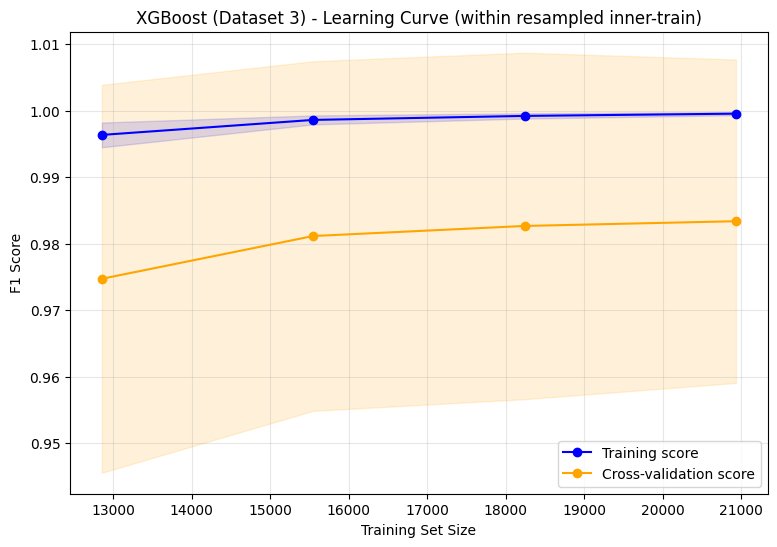

Final training score: 1.000
Final CV score: 0.983
Train-CV gap: 0.016


In [13]:
xgb_gap = plot_learning_curve(xgb_best, X_inner_train, y_inner_train, "XGBoost (Dataset 3)")

<h5> Overfitting check — Validation Curve (XGBoost, max_depth)

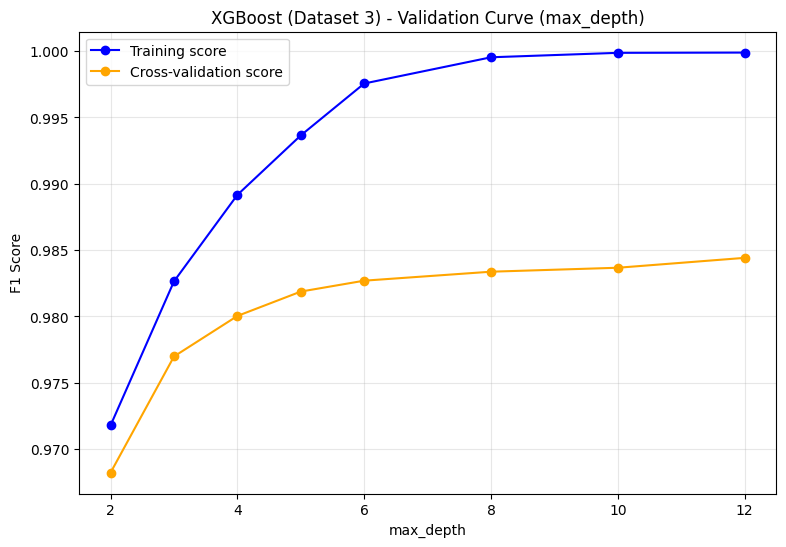

In [14]:
depth_range_xgb = [2, 3, 4, 5, 6, 8, 10, 12]

plot_validation_curve(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='auc',
                  n_estimators=xgb_search.best_params_['n_estimators'],
                  learning_rate=xgb_search.best_params_['learning_rate'],
                  reg_lambda=xgb_search.best_params_['reg_lambda'],
                  gamma=xgb_search.best_params_['gamma']),
    X_inner_train, y_inner_train, param_name='max_depth', param_range=depth_range_xgb,
    model_name="XGBoost (Dataset 3)"
)

<h5> SHAP Analysis — XGBoost (Dataset 3)

===== XGBoost (Dataset 3 - SMOTE) — SHAP Analysis (Inner-Validation) =====


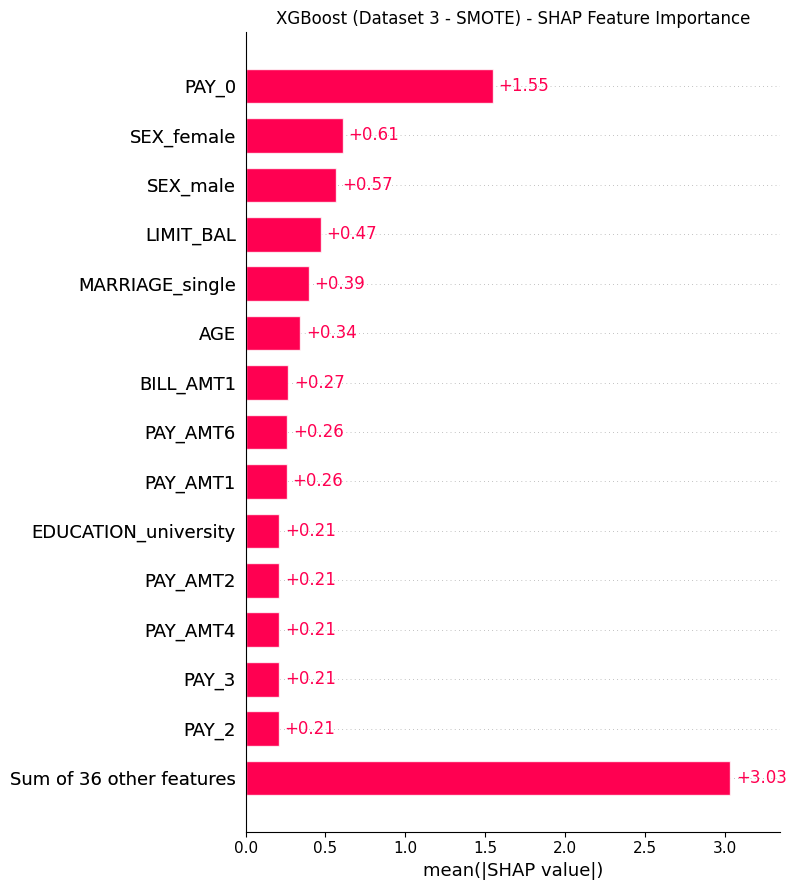

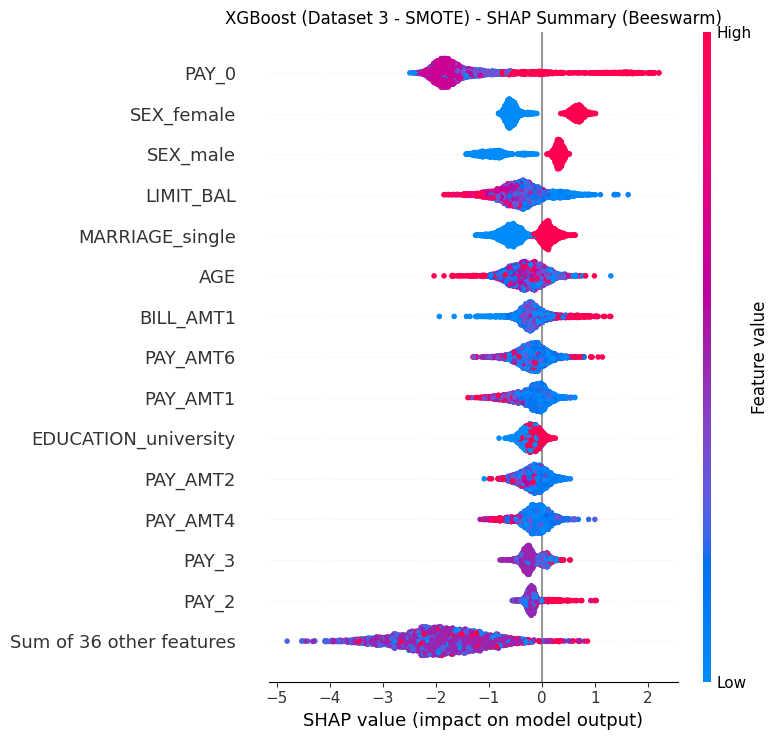

In [15]:
xgb_shap_values = plot_shap_analysis(xgb_best, X_inner_val, "XGBoost (Dataset 3 - SMOTE)")

<h5> LightGBM: train + tune (RandomizedSearchCV)

Best LightGBM params: {'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.1}
===== LightGBM (Dataset 3 - SMOTE) =====

--- Training Set Performance (balanced inner-train) ---
              precision    recall  f1-score   support

           0      0.999     1.000     0.999     13083
           1      1.000     0.999     0.999     13083

    accuracy                          0.999     26166
   macro avg      0.999     0.999     0.999     26166
weighted avg      0.999     0.999     0.999     26166

Training Accuracy: 0.9994

--- Inner-Validation Performance (real, imbalanced) ---
              precision    recall  f1-score   support

           0      0.973     0.993     0.983      3271
           1      0.154     0.043     0.067        93

    accuracy                          0.967      3364
   macro avg      0.564     0.518     0.525      3364
weighted avg      0.951     0.967     0.958      3364

Validation Accuracy: 0.9670

Train ROC-A

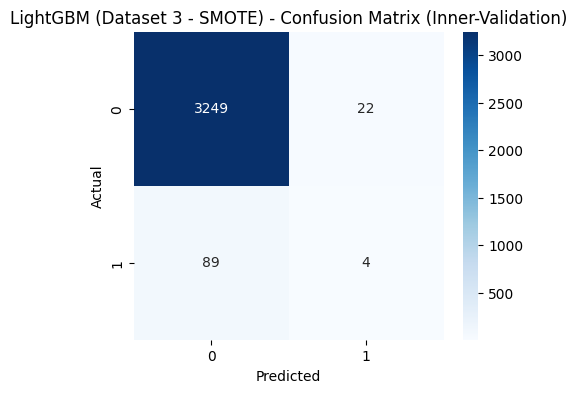

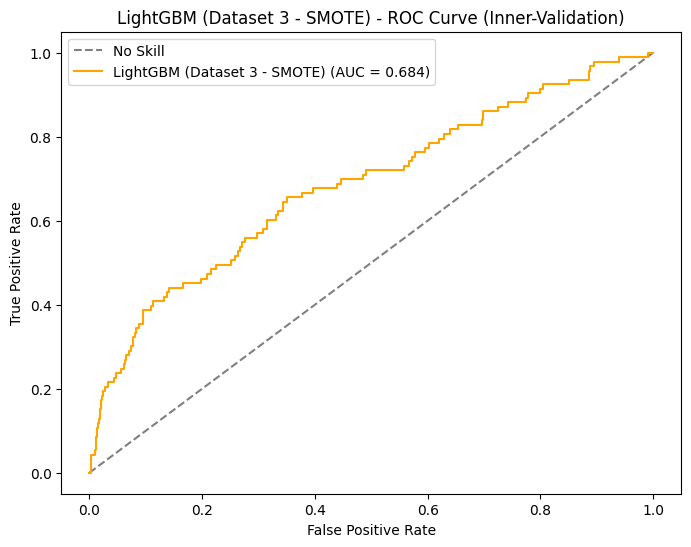

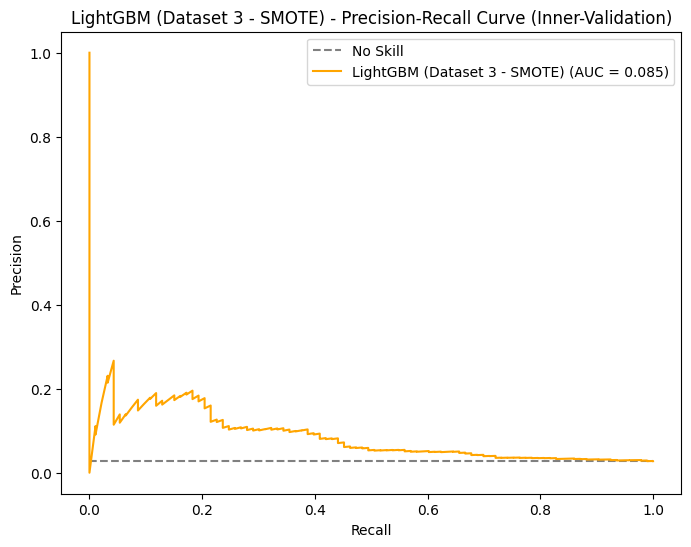


Model saved as: LightGBM_Dataset_3_-_SMOTE.pkl


In [16]:
lgbm_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8, -1],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [15, 31, 63],
    'min_child_samples': [10, 20, 30]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)

lgbm_search.fit(X_inner_train, y_inner_train)
print(f"Best LightGBM params: {lgbm_search.best_params_}")

lgbm_best = lgbm_search.best_estimator_
lgbm_results = evaluate_model(lgbm_best, X_inner_train, y_inner_train, X_inner_val, y_inner_val, "LightGBM (Dataset 3 - SMOTE)")

<h5> Overfitting check — Learning Curve (LightGBM)

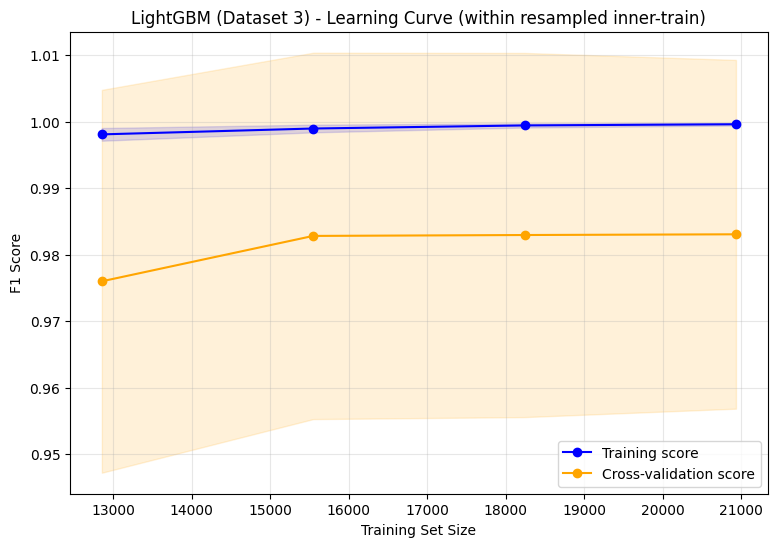

Final training score: 1.000
Final CV score: 0.983
Train-CV gap: 0.017


In [17]:
lgbm_gap = plot_learning_curve(lgbm_best, X_inner_train, y_inner_train, "LightGBM (Dataset 3)")

<h5> Overfitting check — Validation Curve (LightGBM, max_depth)

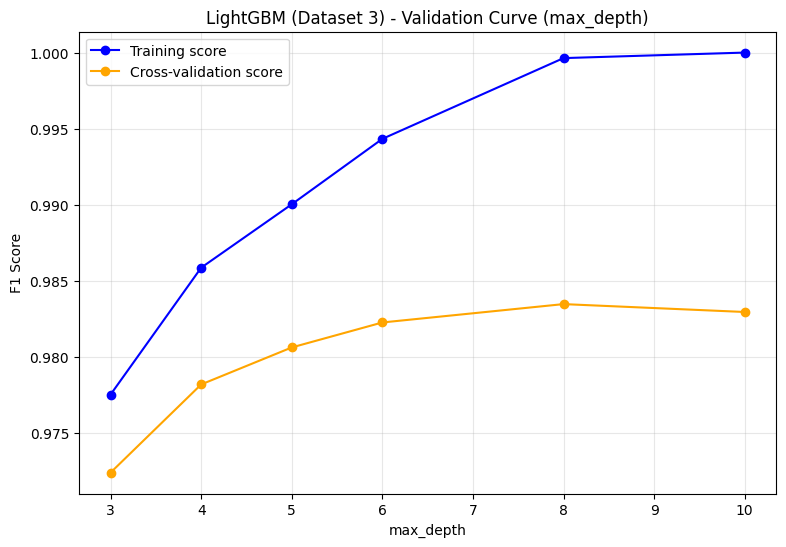

In [18]:
depth_range_lgbm = [3, 4, 5, 6, 8, -1]
depth_range_lgbm_display = [d if d != -1 else 10 for d in depth_range_lgbm]

plot_validation_curve(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1,
                    n_estimators=lgbm_search.best_params_['n_estimators'],
                    learning_rate=lgbm_search.best_params_['learning_rate'],
                    num_leaves=lgbm_search.best_params_['num_leaves'],
                    min_child_samples=lgbm_search.best_params_['min_child_samples']),
    X_inner_train, y_inner_train, param_name='max_depth', param_range=depth_range_lgbm,
    model_name="LightGBM (Dataset 3)", param_range_display=depth_range_lgbm_display
)

<h5> SHAP Analysis — LightGBM (Dataset 3)

===== LightGBM (Dataset 3 - SMOTE) — SHAP Analysis (Inner-Validation) =====


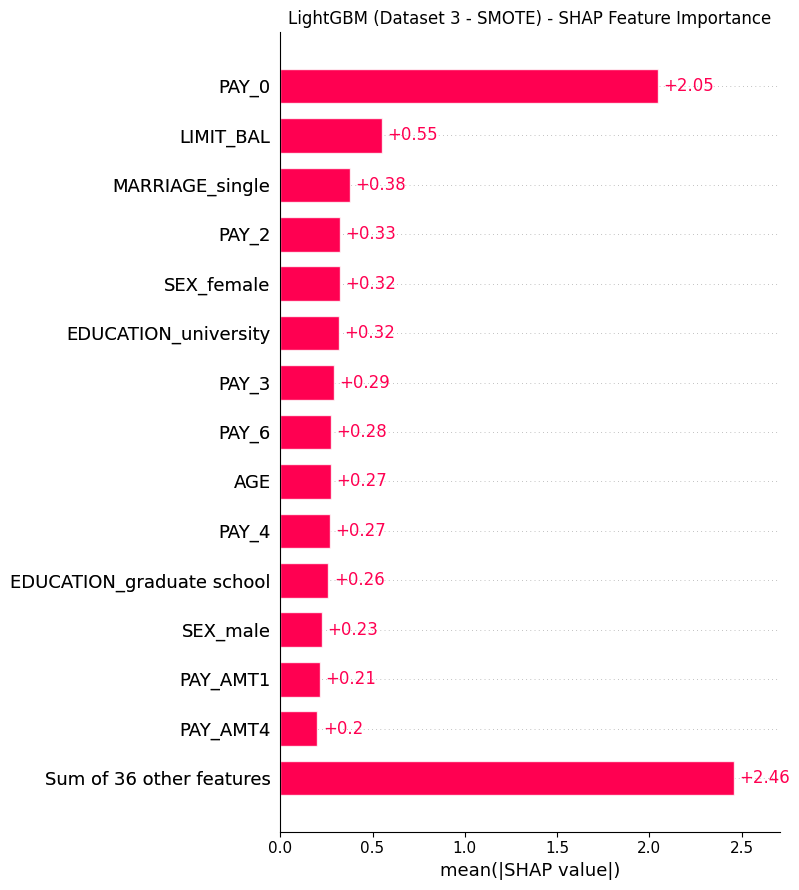

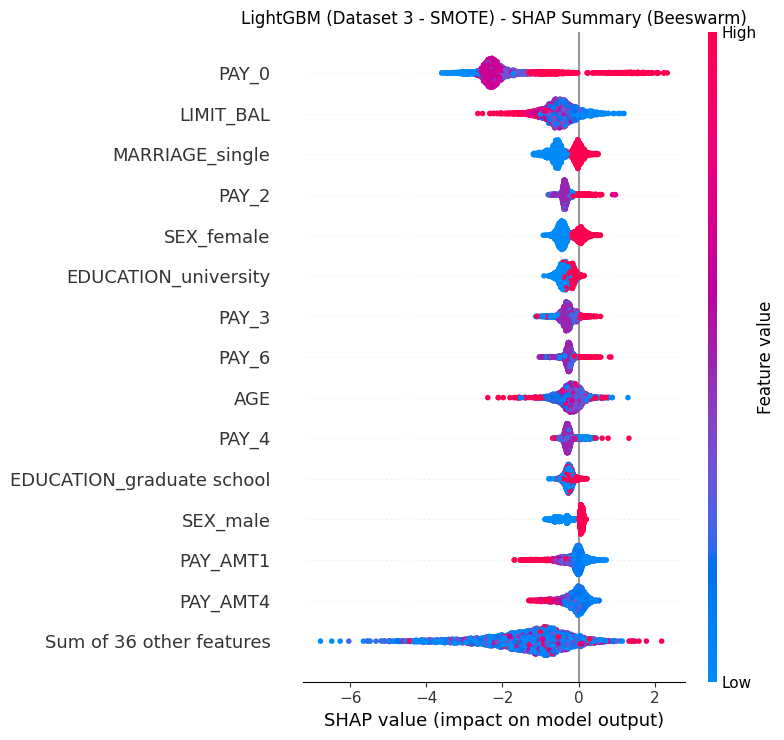

In [19]:
lgbm_shap_values = plot_shap_analysis(lgbm_best, X_inner_val, "LightGBM (Dataset 3 - SMOTE)")

<h5> Final Comparison Table (Dataset 3)

In [22]:
comparison_df = pd.DataFrame([rf_results, xgb_results, lgbm_results])
comparison_df['retuned'] = ['No', 'No', 'No']
comparison_df[['model_name', 'retuned', 'f1_val', 'accuracy_val', 'roc_auc_val', 'pr_auc_val', 'recall_val']]

,model_name,retuned,f1_val,accuracy_val,roc_auc_val,pr_auc_val,recall_val
0,Random Forest (Dataset 3 - SMOTE),No,0.122137,0.965815,0.726798,0.106550,0.086022
1,XGBoost (Dataset 3 - SMOTE),No,0.068966,0.967895,0.689030,0.081829,0.043011
2,LightGBM (Dataset 3 - SMOTE),No,0.067227,0.967004,0.684441,0.084963,0.043011


## Dataset 3 (SMOTE) — Closing Summary

**Final results (inner-validation, real 3,271:93):**

| Model | Gap | F1 | ROC-AUC | PR-AUC | Recall |
|---|---|---|---|---|---|
| **Random Forest** | 0.014 | 0.122 | **0.727** | **0.107** | **0.086** |
| XGBoost | 0.016 | 0.069 | 0.689 | 0.082 | 0.043 |
| LightGBM | 0.017 | 0.067 | 0.684 | 0.085 | 0.043 |

**Overfitting checks:**

* All three models passed cleanly on first pass — no retuning needed (gaps 0.014–0.017, the tightest cluster across all three datasets)
* Despite the much larger, fully-balanced 26,166-row inner-train (vs. 744 rows in Datasets 1/2), none of the three models overfit — SMOTE's synthetic interpolation combined with scaling appears to produce well-behaved training dynamics

**Key findings:**

* Random Forest is the clear leader on this dataset — best ROC-AUC, PR-AUC, F1, and recall of the three, a different pattern from Datasets 1/2 where LightGBM tended to lead
* All three models show reasonable ranking ability (ROC-AUC 0.68–0.73) but very low recall at the standard 0.5 threshold (0.043–0.086) — a Dataset 3-specific pattern not seen in Dataset 1, where recall was 0.58–0.61 at the same threshold
* This points to a probability-calibration issue: models trained on SMOTE-balanced data don't naturally produce probabilities well-suited to a 0.5 cutoff when evaluated on real, heavily imbalanced data

**SHAP — a genuine bias finding, confirmed across all three models:**

* PAY_0 dominates in every model, as expected and consistent with EDA and Datasets 1/2
* Unlike Datasets 1/2, demographic features (`SEX_female`/`SEX_male`, `MARRIAGE_single`, `EDUCATION_university`/`graduate school`) rank unusually high across all three models — well beyond the modest 2-4 percentage-point differences these groups showed in EDA
* Since this appears consistently across three structurally different algorithms, the likely cause is SMOTE itself: synthetic interpolation across the small real minority class (372 rows) appears to amplify demographic splits present in that small sample across the much larger synthetic pool (12,711 rows)
* This is a genuine, evidence-backed bias concern specific to SMOTE, not present in Dataset 1's simple undersampling approach

**Pipeline recap:**

* Loaded only 70% outer-train, OG test set untouched
* 80:20 stratified split (`random_state=42`, identical to Datasets 1/2) → inner-train-raw / inner-validation (3,364 rows, shared across all three notebooks)
* Features scaled (`StandardScaler`, fit on inner-train-raw only) *before* SMOTE 
* SMOTE applied to scaled inner-train-raw only → 26,166 rows (13,083:13,083)
* RF/XGBoost/LightGBM tuned via `RandomizedSearchCV`, all three passed the overfitting check on first pass
* All three evaluated once on untouched (scaled) inner-validation — metrics + curves + SHAP
* Comparison table built from `evaluate_model()` output dicts